In [1]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import plotly.express as px
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# Load the persisted data from Notebook 1
df_clean = pd.read_parquet('group2_stocks.parquet')
df_benchmark = pd.read_parquet('benchmark.parquet')
# 2. Re-calculate Log Returns (The "Price Profile")
# Mathematically: $r_t = \ln(P_t / P_{t-1})$
log_returns = np.log(df_clean / df_clean.shift(1)).fillna(0)

print(f"✅ Data loaded successfully. stocks: {df_clean.shape}, benchmark: {df_benchmark.shape}")

✅ Data loaded successfully. stocks: (500, 100), benchmark: (500, 1)


In [2]:
# --- CELL: DEC PREPROCESSING (PRICE PROFILE) ---
from sklearn.preprocessing import StandardScaler

# 1. Prepare the Data
# Transpose so rows = stocks, columns = days
# We use the log_returns calculated in Cell 3
X_price = log_returns.T 

# 2. Standardize (Z-Score)
# This creates a "Price Profile" where every stock has Mean=0, Std=1
# The AE will learn the *shape* of the returns (correlation structures)
scaler_price = StandardScaler()
X_price_scaled = scaler_price.fit_transform(X_price)

# 3. Check Shape
print(f"Input Shape for Autoencoder: {X_price_scaled.shape}")
# Should be approximately (101, 503) or similar, depending on trading days

Input Shape for Autoencoder: (100, 500)


In [3]:
# --- BRIDGE CELL: FEATURE SCALING & METADATA ---
from sklearn.preprocessing import StandardScaler

# 1. Define 'tickers' from the data columns
# This resolves the "NameError: name 'tickers' is not defined"
tickers = df_clean.columns.tolist()

# 2. Prepare the Price Profile Feature Matrix
# We transpose so that rows = Stocks (101) and columns = Trading Days (features)
X_price = log_returns.T 

# 3. Standardization (Z-Score)
# Neural networks converge much faster when inputs are centered at 0 with unit variance.
scaler = StandardScaler()
X_price_scaled = scaler.fit_transform(X_price)

print(f"✅ Pre-processing Complete.")
print(f"Total Stocks (Rows): {len(tickers)}")
print(f"Feature Matrix Shape: {X_price_scaled.shape}")

✅ Pre-processing Complete.
Total Stocks (Rows): 100
Feature Matrix Shape: (100, 500)


### AutoEncoder building & Sanity checks

C:\Users\AJITH\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


Training Model 1 (Large/Overfit)...
Training Model 2 (Selected/Robust)...
Training Model 3 (Small/Underfit)...
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/stepWARNING:tensorflow:6 out of the last 12 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x000002C72256BEC0> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step


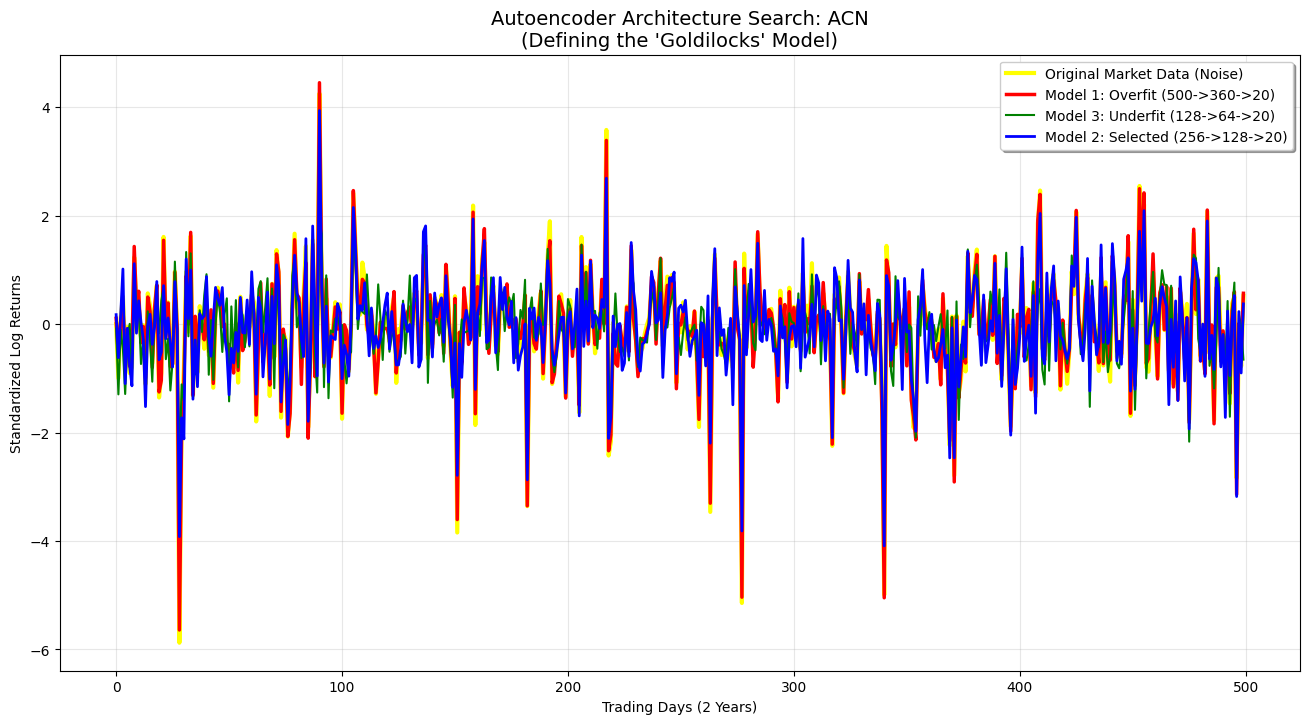

Model 1: Overfit Loss: 0.2141
Model 2: Selected Loss: 0.3081
Model 3: Underfit Loss: 0.3982


In [4]:
# --- CELL 6 (COMPARATIVE): ARCHITECTURE SANITY CHECK ---
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, GaussianNoise
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2

# Configuration
input_dim = X_price_scaled.shape[1]  # Number of trading days (features)
encoding_dim = 20                    # Bottleneck size
EPOCHS = 100
BATCH_SIZE = 16

# ==========================================
# MODEL 1: THE "LARGE" MODEL (Overfitting)
# Structure: 500 -> 360 -> 20
# Flaw: Too many neurons
# ==========================================
input_large = Input(shape=(input_dim,))
noisy_inputl = GaussianNoise(0.1)(input_large) # Corrupt input with noise
e1_l = Dense(500, activation='relu', kernel_regularizer=l2(0.001))(noisy_inputl)
e2_l = Dense(360, activation='relu', kernel_regularizer=l2(0.001))(e1_l)
latent_l = Dense(encoding_dim, activation='linear')(e2_l)

d1_l = Dense(500, activation='relu', kernel_regularizer=l2(0.001))(latent_l)
d2_l = Dense(360, activation='relu', kernel_regularizer=l2(0.001))(d1_l)
output_large = Dense(input_dim, activation='linear')(d2_l)

autoencoder_large = Model(input_large, output_large)
autoencoder_large.compile(optimizer='adam', loss='mse')

print("Training Model 1 (Large/Overfit)...")
# FIX 1: Capture the history object
history_large = autoencoder_large.fit(X_price_scaled, X_price_scaled, epochs=EPOCHS, batch_size=BATCH_SIZE, verbose=0)


# ==========================================
# MODEL 2: THE "SELECTED" MODEL (Robust)
# Structure: Noise -> 256 -> 128 -> 20
# Strength: Denoising + L2 Regularization. Learns structure.
# ==========================================
input_sel = Input(shape=(input_dim,),name="Input_Layer")
noisy_input = GaussianNoise(0.1)(input_sel) # Corrupt input with noise

# Encoder (with L2 regularization)
e1_s = Dense(256, activation='relu', kernel_regularizer=l2(0.001), name="Encoder_Hidden_1")(noisy_input)
e2_s = Dense(128, activation='relu', kernel_regularizer=l2(0.001), name="Encoder_Hidden_2")(e1_s)
latent_sel = Dense(encoding_dim, activation='linear', name="Latent_Bottleneck")(e2_s)

# Decoder
d1_s = Dense(256, activation='relu', kernel_regularizer=l2(0.001), name="Decoder_Hidden_1")(latent_sel)
d2_s = Dense(128, activation='relu', kernel_regularizer=l2(0.001), name="Decoder_Hidden_2")(d1_s)
output_sel = Dense(input_dim, activation='linear', name="Output_Layer")(d2_s)

autoencoder_selected = Model(input_sel, output_sel)
# We need a separate encoder model to extract features later
encoder_model_selected = Model(input_sel, latent_sel) 

autoencoder_selected.compile(optimizer=Adam(learning_rate=0.001), loss='mse')

print("Training Model 2 (Selected/Robust)...")
# FIX 1: Capture the history object
history_selected = autoencoder_selected.fit(X_price_scaled, X_price_scaled, epochs=EPOCHS, batch_size=BATCH_SIZE, verbose=0)


# ==========================================
# MODEL 3: THE "SMALL" MODEL (Underfitting)
# Structure: 128 -> 64 -> 20
# Flaw: Too weak to capture complex market moves.
# ==========================================
input_small = Input(shape=(input_dim,))
noisy_inputs = GaussianNoise(0.1)(input_small) # Corrupt input with noise
e1_sm = Dense(128, activation='relu', kernel_regularizer=l2(0.001))(noisy_inputs)
e2_sm = Dense(64, activation='relu', kernel_regularizer=l2(0.001))(e1_sm)
latent_sm = Dense(encoding_dim, activation='linear')(e2_sm)

d1_sm = Dense(128, activation='relu', kernel_regularizer=l2(0.001))(latent_sm)
d2_sm = Dense(64, activation='relu', kernel_regularizer=l2(0.001))(d1_sm)
output_small = Dense(input_dim, activation='linear')(d2_sm)

autoencoder_small = Model(input_small, output_small)
autoencoder_small.compile(optimizer='adam', loss='mse')

print("Training Model 3 (Small/Underfit)...")
# FIX 1: Capture the history object
history_small = autoencoder_small.fit(X_price_scaled, X_price_scaled, epochs=EPOCHS, batch_size=BATCH_SIZE, verbose=0)


# ==========================================
# PLOTTING THE COMPARISON
# ==========================================
# 1. Get Predictions
pred_large = autoencoder_large.predict(X_price_scaled)
pred_selected = autoencoder_selected.predict(X_price_scaled)
pred_small = autoencoder_small.predict(X_price_scaled)

# 2. Select Stock to Visualize (e.g., Google or Index 1)
stock_idx = 1 
stock_name = tickers[stock_idx]

plt.figure(figsize=(16, 8))

# A. Original Data (Grey/Yellow Background)
plt.plot(X_price_scaled[stock_idx], color='yellow', label='Original Market Data (Noise)', linewidth=3)

# B. Large Model (Green Dashed)
plt.plot(pred_large[stock_idx], color='red', linewidth=2.5, 
         label='Model 1: Overfit (500->360->20)')

# C. Small Model (Red Dotted)
plt.plot(pred_small[stock_idx], color='green', linewidth=1.5, 
         label='Model 3: Underfit (128->64->20)')

# D. Selected Model (Blue Solid - The Winner)
plt.plot(pred_selected[stock_idx], color='blue', linewidth=2, 
         label='Model 2: Selected (256->128->20)')

plt.title(f"Autoencoder Architecture Search: {stock_name}\n(Defining the 'Goldilocks' Model)", fontsize=14)
plt.xlabel("Trading Days (2 Years)")
plt.ylabel("Standardized Log Returns")
plt.legend(loc='upper right', frameon=True, shadow=True)
plt.grid(True, alpha=0.3)
plt.show()

# FIX 2: Use the captured history objects to print loss
print(f"Model 1: Overfit Loss: {history_large.history['loss'][-1]:.4f}")
print(f"Model 2: Selected Loss: {history_selected.history['loss'][-1]:.4f}")
print(f"Model 3: Underfit Loss: {history_small.history['loss'][-1]:.4f}")

### Architecture Summary

In [5]:
# --- CELL 15: VISUAL ARCHITECTURE SUMMARY ---
from tensorflow.keras.utils import plot_model

# 1. Standard Text Summary
print("--- Textual Architecture Summary ---")
autoencoder_selected.summary()

# 2. Visual Graph (Saves as a file and displays)
# Note: Requires 'pydot' and 'graphviz' installed in your environment
try:
    plot_model(
        autoencoder_selected, 
        show_shapes=True, 
        show_layer_names=True, 
        to_file='ae_architecture.png'
    )
    print("\nArchitecture graph saved as 'ae_architecture.png'")
except ImportError:
    print("\n[Note] Install pydot and graphviz for the visual graph output.")

--- Textual Architecture Summary ---


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ Input_Layer (InputLayer)             │ (None, 500)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ gaussian_noise_1 (GaussianNoise)     │ (None, 500)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Encoder_Hidden_1 (Dense)             │ (None, 256)                 │         128,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Encoder_Hidden_2 (Dense)             │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Latent_Bottleneck (Dense)            │ (None, 20)                  │           2,580 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Decoder_Hidden_1 (Dense)             │ (None, 256)                 │           5,376 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Decoder_Hidden_2 (Dense)             │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Output_Layer (Dense)                 │ (None, 500)                 │          64,500 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 799,514 (3.05 MB)

 Trainable params: 266,504 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 533,010 (2.03 MB)


Architecture graph saved as 'ae_architecture.png'


### Finding Optimal K for Latent Features

Extracting latent features from Model 2...
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
Deep Feature Matrix Shape: (100, 20)
Running K-Means on Deep Features to find optimal k...


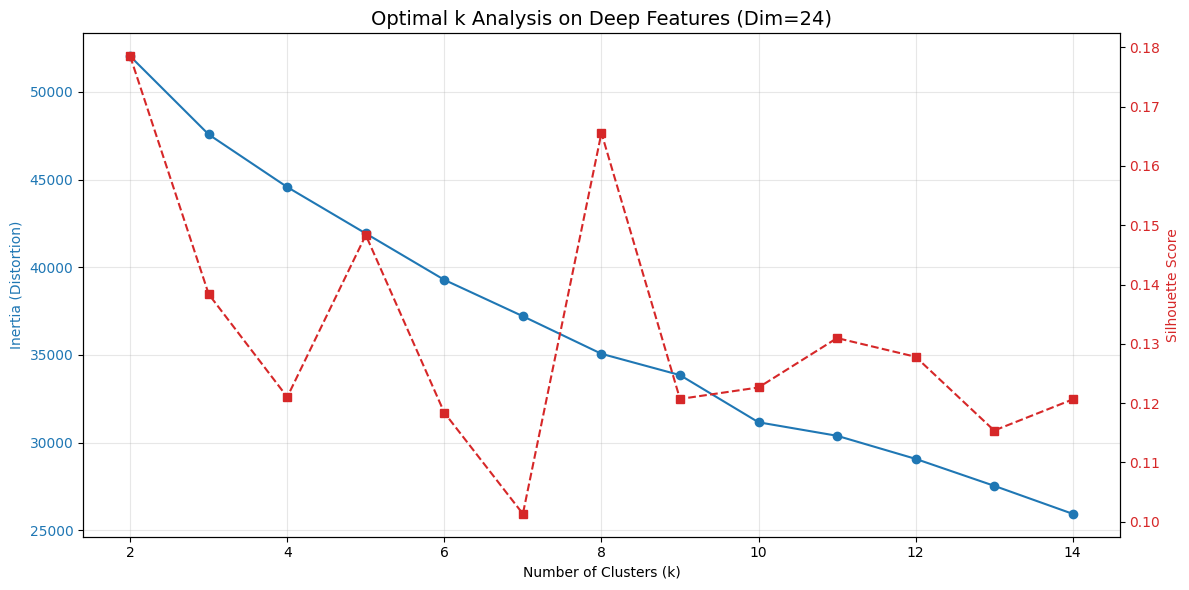

--- SUGGESTION ---
Highest Silhouette Score is at k = 2


In [6]:
# --- CELL 8: FEATURE EXTRACTION & OPTIMAL K SEARCH ---
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import seaborn as sns
import numpy as np

# 1. Extract the "Deep Features" (Latent Space)
# We use the encoder from your "Selected" model
print("Extracting latent features from Model 2...")
encoded_features = encoder_model_selected.predict(X_price_scaled)
print(f"Deep Feature Matrix Shape: {encoded_features.shape}") 
# Expected: (101, 24)

# 2. Determine Optimal K (Elbow Method & Silhouette)
inertias = []
silhouettes = []
K_range = range(2, 15) # Check for 2 to 14 clusters

print("Running K-Means on Deep Features to find optimal k...")

for k in K_range:
    # We use k-means++ for smart initialization
    kmeans = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    kmeans.fit(encoded_features)
    
    inertias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(encoded_features, kmeans.labels_))

# 3. Plot the Analysis
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot Inertia (Elbow) - Blue Line
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia (Distortion)', color='tab:blue')
ax1.plot(K_range, inertias, 'o-', color='tab:blue', label='Inertia (Elbow)')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.grid(True, alpha=0.3)

# Plot Silhouette Score - Red Line
ax2 = ax1.twinx() 
ax2.set_ylabel('Silhouette Score', color='tab:red') 
ax2.plot(K_range, silhouettes, 's--', color='tab:red', label='Silhouette Score')
ax2.tick_params(axis='y', labelcolor='tab:red')

plt.title(f"Optimal k Analysis on Deep Features (Dim=24)", fontsize=14)
fig.tight_layout()
plt.show()

# 4. Auto-Suggest Best K
best_k_silhouette = K_range[np.argmax(silhouettes)]
print(f"--- SUGGESTION ---")
print(f"Highest Silhouette Score is at k = {best_k_silhouette}")


--- DEC CLUSTER ASSIGNMENTS (Total Clusters: 2) ---

📂 CLUSTER #0 (39 stocks):
ALLE, AMAT, AVGO, BEN, BLDR, BX, CMI, CRH, CVNA, EMR, FCX, FFIV, FITB, FIX, GNRC, GOOG, HST, HUBS, INTC, IQV, JBHT, KLAC, LEN, MLM, MTD, NXPI, PPG, PTC, RJF, ROK, RVTY, SWK, TEL, TFC, TSLA, UBER, VLO, WAT, WFC

📂 CLUSTER #1 (61 stocks):
ABBV, ACN, ADM, AIG, AMCR, AMT, AON, AWK, AZO, BDX, CCI, CI, CINF, CL, CMCSA, CSCO, CVS, CVX, DLTR, DRI, DTE, EG, ELV, EQIX, ETR, FANG, GEN, GPC, HIG, HOLX, HWM, JKHY, KDP, KVUE, LMT, MA, MCD, MCK, MO, MSCI, MSI, NEE, NFLX, NOC, O, ORLY, OXY, PAYX, PGR, PNW, ROST, SPG, STZ, T, TMO, VRSK, VRSN, VZ, WEC, WMT, WY


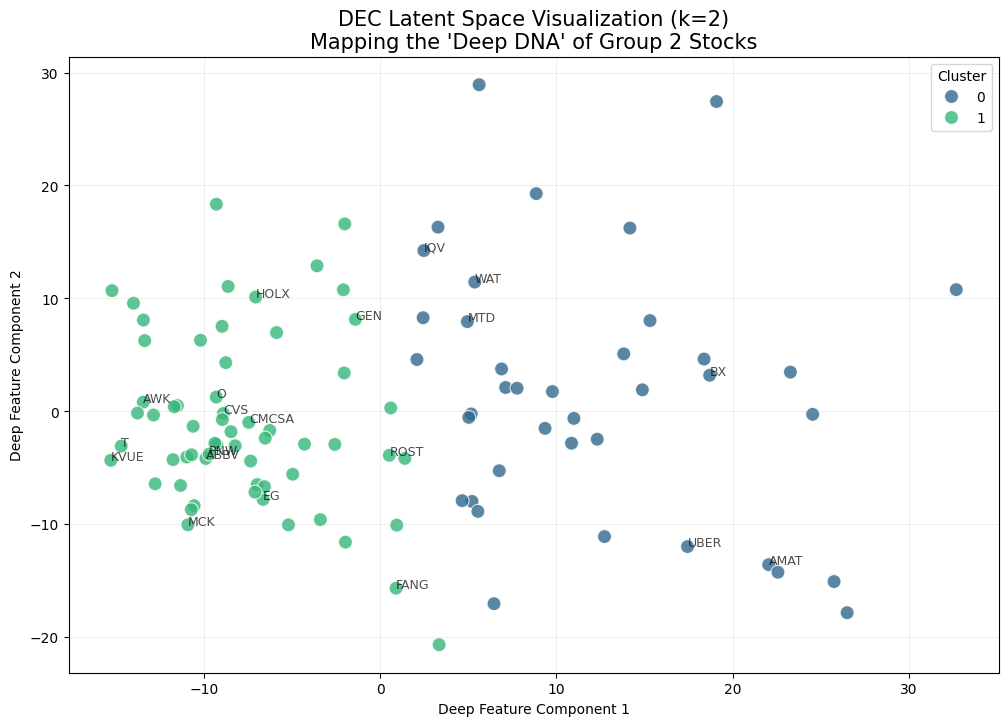

In [7]:
# --- CELL 9: DEC CLUSTER ASSIGNMENTS & VISUALIZATION ---
from sklearn.decomposition import PCA
import seaborn as sns

# 1. Run the Final K-Means on the Deep Features
# We use the best_k_silhouette found in the previous cell (or force 2)
k_final = best_k_silhouette 
kmeans_final = KMeans(n_clusters=k_final, init='k-means++', n_init=10, random_state=42)
cluster_labels = kmeans_final.fit_predict(encoded_features)

# 2. Create the Results DataFrame
dec_results = pd.DataFrame({
    'Ticker': tickers,
    'Cluster': cluster_labels
})

# 3. Print the Stocks in each Cluster
print(f"--- DEC CLUSTER ASSIGNMENTS (Total Clusters: {k_final}) ---")
for i in range(k_final):
    cluster_stocks = dec_results[dec_results['Cluster'] == i]['Ticker'].tolist()
    print(f"\n📂 CLUSTER #{i} ({len(cluster_stocks)} stocks):")
    print(", ".join(cluster_stocks))

# 4. Visualize the "Deep Latent Space" in 2D
# We project the 20-dimensional deep features into 2 (PC1 and PC2)
pca_2d = PCA(n_components=2)
latent_2d = pca_2d.fit_transform(encoded_features)

plt.figure(figsize=(12, 8))
sns.scatterplot(
    x=latent_2d[:, 0], y=latent_2d[:, 1], 
    hue=cluster_labels, palette='viridis', s=100, alpha=0.8, edgecolor='w'
)

# Annotate a few stocks for context
for i, ticker in enumerate(tickers):
    if i % 5 == 0: # Annotate every 5th stock to keep the plot clean
        plt.annotate(ticker, (latent_2d[i, 0], latent_2d[i, 1]), alpha=0.7, fontsize=9)

plt.title(f"DEC Latent Space Visualization (k={k_final})\nMapping the 'Deep DNA' of Group 2 Stocks", fontsize=15)
plt.xlabel("Deep Feature Component 1")
plt.ylabel("Deep Feature Component 2")
plt.legend(title="Cluster", loc='best')
plt.grid(True, alpha=0.2)
plt.show()

In [8]:
dec_results.to_csv('labels_dec.csv', index=False)